In [1]:
import math
from typing import Callable
import numpy as np

def prom_update(prom_prev: float, x_new: float, n_curr: int):
    if n_curr < 1:
        raise Exception()
    elif n_curr == 1:
        return x_new
    else:
        return prom_prev + (x_new - prom_prev) / n_curr


def s_cuad_update(s_cuad_prev: float, prom_prev: float, prom_curr: float, n_curr: int):
    if n_curr < 1:
        raise Exception()
    elif n_curr == 1:
        return 0.0
    else:
        return (1 - (1/(n_curr - 1))) * s_cuad_prev + n_curr * ((prom_curr - prom_prev)**2)

Un supermercado pequeño cuenta con $N$ cajas registradoras en servicio y con $S$ máquinas de repuesto, todas ellas de idéntica marca, modelo y antigüedad. Además el supermercado cuenta con los servicios de un técnico que repara las máquinas. El técnico repara las máquinas en serie, encargándose de una sola por vez. El fallo del sistema ocurre cuando se tienen menos de $N$ cajas en servicio, o lo que es lo mismo, se poseen más de $S$ cajas registradoras defectuosas en el taller. <br>
Todos los tiempos de funcionamiento de las cajas hasta descomponerse son variables independientes exponenciales con un tiempo medio hasta fallar de $T_F$ , y el tiempo de reparación de una caja que ingresa a taller es una variable exponencial con tiempo medio igual a $T_R$, independiente de todos los anteriores.


### Ejercicio 2. Problema de Reparación con dos operarios
El supermercado desea aumentar el tiempo medio del sistema y para esto analiza la posibilidad de contratar dos operarios, o bien comprar otra caja extra como repuesto. Para estudiar cual es la mejor alternativa, reconsidere el problema de reparación asumiendo que el taller tiene dos operarios igualmente idóneos que
trabajan en paralelo.

1. Escribir un programa para simular el modelo de reparación con dos colas.

2. Inicializar el programa con los tiempos de fallos de cada una las cajas en uso, y ejecutarlo para estimar el tiempo medio de fallo del sistema y su correspondiente desviación estándar. Utilizar nuevamente $N = 7, S = 3$ y que el tiempo medio de fallo de una caja es de un mes. Suponga nuevamente cada
operario del taller emplea un tiempo aleatorio con distribución exponencial de media igual a $1/8$ de mes para brindar servicio a una caja descompuesta.

3. Construir un histograma con los tiempos de fallo a partir de $10000$ simulaciones. Analizar las características del histograma.

4. Comparar los resultados con la situación en que se agregue una máquina de repuesto en lugar de agregar un operario. Realizar pruebas de bondad de ajuste para ambas situaciones.


In [2]:
def reparacion_2_operarios_paralelo(
        n: int,
        s: int,
        t_funcionamiento: Callable[[], float],
        t_reparacion_operario_1: Callable[[], float],
        t_reparacion_operario_2: Callable[[], float]
    ):
    # Inicialización
    t, r = 0, 0

    # Arreglo de tiempos de funcionamiento de las cajas registradoras
    T = []
    for _ in range(n):
        T.append(t + t_funcionamiento())
    T.sort()

    # Tiempo en el cual estará reparada una caja registradora por el operario 1 y 2
    t_estrella_1 = math.inf
    t_estrella_2 = math.inf

    while r <= s:
        evento_prox = min(min(T), t_estrella_1, t_estrella_2)

        if evento_prox in T:  # Fallo una caja registradora
            t = evento_prox
            r += 1

            # Se rompió la caja registradora i
            i = T.index(evento_prox)

            if r > s:
                break

            if r == 1 and t_estrella_1 == math.inf:
                t_estrella_1 = t + t_reparacion_operario_1()
            elif r == 1 and t_estrella_2 == math.inf:
                t_estrella_2 = t + t_reparacion_operario_1()

            T[i] = math.inf

        elif evento_prox == t_estrella_1:  # El operario 1 reparo una caja registradora
            t = t_estrella_1
            j = T.index(math.inf)
            r -= 1

            # Se repara la caja registradora j
            T[j] = t + t_funcionamiento()

            if r > 0 and (t_estrella_2 == math.inf or r > 1):
                # Hay cajas registradoras rotas y el segundo técnico no esta
                # reparando ninguna o hay que reparar mas de una.

                t_estrella_1 = t + t_reparacion_operario_1()
            else:
                # No hay que repara nada o el segundo técnico esta reparando la
                # única caja registradora rota

                t_estrella_1 = math.inf

            T.sort()

        else:  # evento_prox == t_estrella_2 - El operario 2 reparo una caja registradora
            t = t_estrella_2
            j = T.index(math.inf)
            r -= 1

            # Se repara la caja registradora j
            T[j] = t + t_funcionamiento()
            
            if r > 0 and (t_estrella_1 == math.inf or r > 1):
                # Hay cajas registradoras rotas y el primer técnico no esta
                # reparando ninguna o hay que reparar mas de una.

                t_estrella_2 = t + t_reparacion_operario_2()
            else:
                # No hay que repara nada o el primer técnico esta reparando la
                # única caja registradora rota

                t_estrella_2 = math.inf

            T.sort()

    return t

In [3]:
def t_funcionamiento():
    return -math.log(1 - np.random.random()) * 1

def t_reparacion_operario_1():
    return -math.log(1 - np.random.random()) / 8

def t_reparacion_operario_2():
    return -math.log(1 - np.random.random()) / 8


def generar_t_fallo():
    return reparacion_2_operarios_paralelo(
            7, 3, t_funcionamiento, t_reparacion_operario_1, t_reparacion_operario_2
        )

def punto_b(d: float = 0.01):
    media = generar_t_fallo()
    s_cuad, n = 0, 1

    while n < 100 or math.sqrt(s_cuad / n) >= d:
        X = generar_t_fallo()
        n += 1

        media_prev = media
        media = prom_update(media, X, n)
        s_cuad = s_cuad_update(s_cuad, media_prev, media, n)

    print(f"Cantidad de datos generados: ", n)
    print(f"Tiempo medio hasta la falla del sistema: {media:.4f}")
    print(f"Desviación estándar muestral = {math.sqrt(s_cuad / n):.4f} ")

    return media, s_cuad, n


media, s_cuad, n = punto_b()

Cantidad de datos generados:  77967
Tiempo medio hasta la falla del sistema: 3.0691
Desviación estándar muestral = 0.0100 


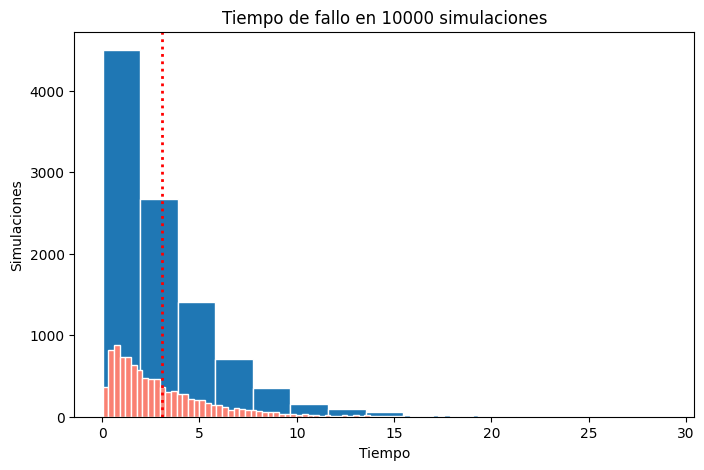

In [8]:
# Punto 3
import matplotlib.pyplot as plt

N_SIM = 10_000
datos = [generar_t_fallo() for _ in range(N_SIM)]

plt.figure(figsize=(8, 5))
plt.hist(datos, bins="sturges", edgecolor="white")

plt.hist(datos, bins="auto", edgecolor="white", color="salmon")

plt.axvline(x=media, color="red", linestyle='dotted', linewidth=2, label='media')

plt.title(f"Tiempo de fallo en {N_SIM} simulaciones")
plt.xlabel("Tiempo")
plt.ylabel("Simulaciones")
plt.show()

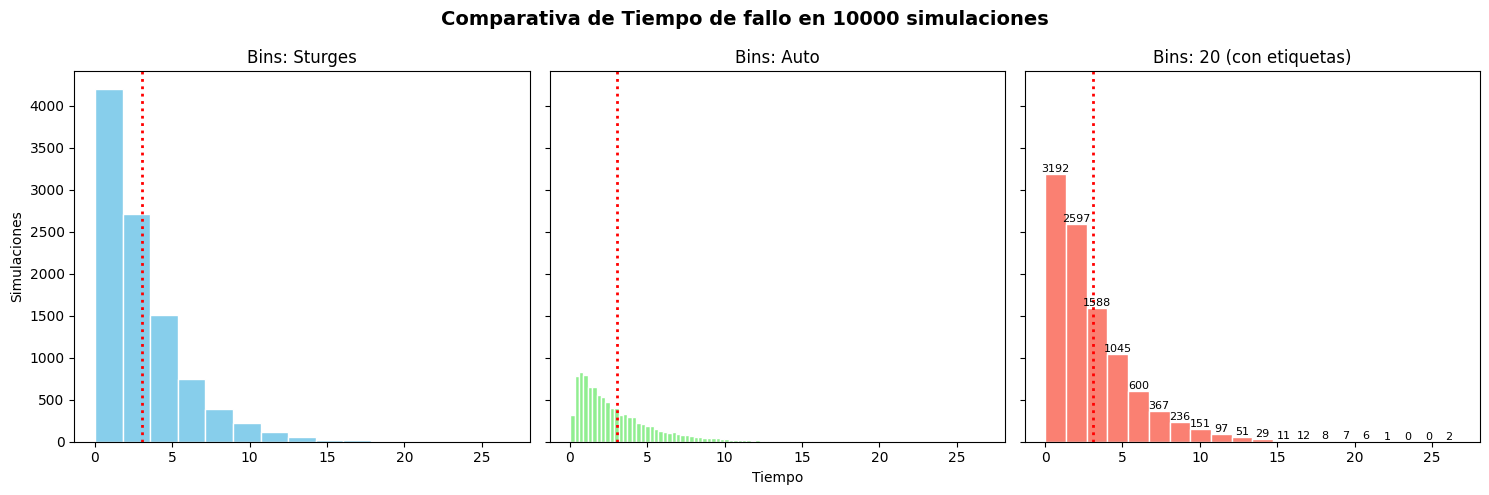

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

axes[0].hist(datos, bins="sturges", edgecolor="white", color="skyblue")
axes[0].axvline(x=media, color="red", linestyle='dotted',
                linewidth=2, label='mu')
axes[0].set_title("Bins: Sturges")
axes[0].set_ylabel("Simulaciones")

axes[1].hist(datos, bins="auto", edgecolor="white", color="lightgreen")
axes[1].axvline(x=media, color="red", linestyle='dotted', linewidth=2)
axes[1].set_title("Bins: Auto")
axes[1].set_xlabel("Tiempo")  # El eje X principal en el centro

_, _, bars = axes[2].hist(datos, bins=20, edgecolor="white", color="salmon")
axes[2].axvline(x=media, color="red", linestyle='dotted', linewidth=2)
axes[2].bar_label(bars, fontsize=8)  # Añade los números sobre las barras
axes[2].set_title("Bins: 20 (con etiquetas)")

fig.suptitle(
    f"Comparativa de Tiempo de fallo en {N_SIM} simulaciones", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()